Tarefa proposta

Será desenvolvido um projeto com foco em fidelização de clientes, com a intenção inicial de identificar e trabalhar com um grupo de maior valor — caracterizado por alto nível de engajamento, recorrência de compras e comportamento de consumo diferenciado.

Como ainda não há um entendimento aprofundado sobre o perfil desses clientes, foi solicitada uma análise exploratória da base disponível para identificar quais indivíduos poderiam ser classificados nesse grupo. Além disso, espera-se extrair insights relevantes que possam orientar futuras ações nas frentes de Marketing, Produto e Negócio.

A proposta consiste em utilizar dados para identificar os clientes que se enquadram nessa categoria e gerar aprendizados acionáveis para suportar a tomada de decisão.

Objetivos:

Analisar a base de dados e identificar clientes com características compatíveis com um perfil de alto valor;
Desenvolver uma análise detalhada desse grupo de clientes;
Gerar insights que possam apoiar estratégias de Produto, Marketing e áreas de negócio.

A análise não precisa se limitar apenas à segmentação, podendo também incluir iniciativas que agreguem valor, como:

Sugestões de recomendação de produtos;
Estimativas de receita associadas ao grupo identificado;
Análises de comportamento de compra, como composição de cestas.

Dataset:

O dataset está no arquivo data.csv, que segue em anexo a este teste.
As colunas contidas neste dataset são:

- InvoiceNo: Código que representa cada transação única.
- StockCode: Código atribuído unicamente a cada produto distinto.
- Description: Descrição de cada produto.
- Quantity: O número de unidades de um produto em uma transação.
- InvoiceDate: A data e a hora da transação.
- UnitPrice: O preço unitário do produto em libras esterlinas.
- CustomerID: Identificador atribuído unicamente a cada cliente.
- Country: O país do cliente.

In [ ]:
import pandas as pd
import numpy as np

from plotnine import *
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.set_option('display.max_rows', 30)
np.set_printoptions(threshold=10)

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

# Lendo a base e observando sua estrutura

In [ ]:
dt = pd.read_csv("data.csv", sep = ",", encoding='latin1')

In [ ]:
dt.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
dt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


- As variáveis *Description* e *CustomerId* são as unicas com valores vazios. Quando eu estiver olhando para cada uma delas decido o que fazer.

# Entendendo cada uma das variáveis

Como temos somente 8 variáveis, podemos olhar para cada uma delas para identificar padrões que nos ajude no entendimento do universo dos dados.

## Feature 1: InvoiceNo

In [ ]:
len(dt['InvoiceNo'].drop_duplicates())

# O universo dos dados possui 25900 transações distintas

25900

Essa coluna representa cada transação, onde cada transação pode conter mais de um produto adquirido.

Possíveis indicadores a serem criados a partir dessa variáveis, a principio:
- Quantidade de produtos distintos comprados por transação;
- Quantidade de transações distintas por clientes geral;
- Quantidade de transações distintas por clientes a cada X tempo, X a definir.






# Feature 2: StockCode

In [ ]:
len(dt['StockCode'].drop_duplicates())

# O universo dos dados possui 4070 SKUs distintos

4070

In [ ]:
print(dt['StockCode'].value_counts())

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
85179a       1
23617        1
90214U       1
47591b       1
72802c       1
Name: count, Length: 4070, dtype: int64


In [ ]:
mask = dt['StockCode'].str.contains(r"gift|PADS", case=False, na=False)
print(f"Qnt. StockCode 'estranho': {len(dt['StockCode'][mask])}\n")


Qnt. StockCode 'estranho': 38



Essa coluna representa o código de identificação de cada SKU.

Possíveis indicadores a serem criados a partir dessa coluna, a principio:
- Quantidade de produtos distintos que o cliente compra por transação;
- Média de produtos distintos que o cliente compra por transação.

Além disso, remover linhas com "gift" e "PADS".

Recomendação para a atribuição dessa coluna: Código hexadecimal ou exclusivamente números.

# Feature 3: Description

In [ ]:
print(dt['Description'].sort_values().unique())

[' 4 PURPLE FLOCK DINNER CANDLES' " 50'S CHRISTMAS GIFT BAG LARGE"
 ' DOLLY GIRL BEAKER' ... 'wrongly sold as sets' 'wrongly sold sets' nan]


In [ ]:
dt_aux = dt['Description'].str.strip()

print(dt_aux.sort_values().unique())

# Existe produtos com descrições estranhas

['*Boombox Ipod Classic' '*USB Office Mirror Ball'
 '10 COLOUR SPACEBOY PEN' ... 'wrongly sold as sets' 'wrongly sold sets'
 nan]


In [ ]:
mask = dt_aux.str.contains(r"wrong|\?", case=False, na=False)
print(f"Qnt. produtos com descrição 'estranha': {len(dt_aux[mask])}\n")

mask = dt_aux.str.contains(r"^ +$", na=True)
print(f"Qnt. produtos com descrição vazia: {len(dt_aux[mask])}\n")

# Existem 1554 produtos registrados com "wrong", "?" ou vazio na sua descrição.
# Vou optar por remover as linhas sob esse padrão, ja que se tratam de poucos casos frente ao universo dos dados.
# Outros padrões estão associados com linhas com CustomerID vazio, que serão removidos mais abaixo.

Qnt. produtos com descrição 'estranha': 100

Qnt. produtos com descrição vazia: 1454



In [ ]:
dt[dt['Description'].isin(["Discount", "Manual", "POSTAGE", "DOTCOM POSTAGE", "SAMPLES"])].shape

# Há 2673 linhas denominadas como Desconto, Manual, Frete e Amostra

(2673, 8)

Ações:

- Remover produtos com descrição vazio, "wrong" ou "?"
- Aplicar ".strip()" para remover espaços vazios antes ou depois da descrição do produto
- Remover linhas com "SAMPLE"
- Remover linhas com "Discount", "Manual", "Postage" e "DOTCOM POSTAGE" que não tenham algum produto associado no InvoiceNo

# Feature 4: Quantity

In [ ]:
dt[(dt['Quantity'] < 0)].shape

(10624, 8)

In [ ]:
dt[(dt['Quantity'] < 0) & ~dt['Description'].isin(["Discount", "Manual", "POSTAGE", "DOTCOM POSTAGE", "SAMPLES"])].shape

(10115, 8)

Ações:

- Remover linhas com Quantity menor que 0 e Description diferente de "Discount", "Manual", "POSTAGE", "DOTCOM POSTAGE", "SAMPLES"

# Feature 5: InvoiceDate

In [ ]:
dt_aux = pd.to_datetime(dt['InvoiceDate']).sort_values()

In [ ]:
print(f"Menor data: {dt_aux[0]}\nMaior data: {dt_aux[len(dt_aux) - 1]}")

Menor data: 2010-12-01 08:26:00
Maior data: 2011-12-09 12:50:00


Período dos dados 01/12/2010 - 09/12/2011

Ações:
- Transformar para o formato de data;
- Criar variáveis, a partir dela, sobre semestre, trimestre, mês e horário;
- Identificar padrões de compra e não-comprar nos clientes para auxiliar no direcionamento de campanhas.


# Feature 6: UnitPrice




In [ ]:
dt['UnitPrice'].describe(percentiles=[.01, .1, .25, .75,  .9, .99, .9990])

# Existem outliers tanto 'para cima' quanto 'para baixo'. A principio penso em removê-los

,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
1%,0.190000
10%,0.630000
25%,1.250000
50%,2.080000
75%,4.130000
90%,7.950000


In [ ]:
dt[(dt['UnitPrice']) <= 0].sort_values(by = "UnitPrice")

# Remover valores menores ou iguais a zero.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom
536908,581226,23090,missing,-338,12/8/2011 9:56,0.00,NaN,United Kingdom
535336,581213,22576,check,-30,12/7/2011 18:38,0.00,NaN,United Kingdom
535335,581212,22578,lost,-1050,12/7/2011 18:38,0.00,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.00,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.00,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.00,NaN,United Kingdom
538919,581422,23169,smashed,-235,12/8/2011 15:24,0.00,NaN,United Kingdom


In [ ]:
dt[(dt['UnitPrice']) > np.quantile(dt['UnitPrice'], q = .9990)].sort_values(by = "UnitPrice")

# A maior parte dos "produtos" com valor unitário maior do que o P90,99 dos preços são serviços ou postagem
# Altos gastos com postagem parecem estar relacionados a compra de muitos produtos por transação. Pode ser um bom indicador

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
86329,543546,DOT,DOTCOM POSTAGE,1,2/9/2011 16:52,206.15,NaN,United Kingdom
405882,571716,DOT,DOTCOM POSTAGE,1,10/18/2011 17:05,206.38,NaN,United Kingdom
304662,C563593,D,Discount,-1,8/18/2011 6:13,206.40,14646.0,Netherlands
247835,558774,DOT,DOTCOM POSTAGE,1,7/4/2011 10:17,206.66,NaN,United Kingdom
92819,544205,DOT,DOTCOM POSTAGE,1,2/17/2011 10:31,207.79,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
16356,C537651,AMAZONFEE,AMAZON FEE,-1,12/7/2010 15:49,13541.33,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,1/5/2011 9:57,16453.71,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,1/5/2011 9:55,16888.02,NaN,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,12/5/2011 11:36,17836.46,NaN,United Kingdom


Ações:
- Remover as linhas com UnitPrice menores do que zero.
- Criar coluna com valor total gasto pelo cliente naquela transação

# Feature 7: CustomerID

In [ ]:
sum(dt["CustomerID"].isna())

# Há 135080 linhas sem a informação de CustomerID. Elas serão removidas, já que o
# estudo é sobre os clientes e nessas linhas não podemos identificá-los.

135080

Ações:
- Remover linhas com o CustomerID vazio

# Feature 8: Country

In [ ]:
dt['Country'].value_counts()

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
...,...
Lithuania,35
Brazil,32
Czech Republic,30


In [ ]:
dt.shape[0] - dt[dt['Country'] != 'United Kingdom'].shape[0]

# A grande maioria das transações são no Reino Unido, numa freq_ratio de 495478/9495 = 52

495478

In [ ]:
dt.groupby("Country").agg(
    total_customers = ('CustomerID', 'nunique')
).reset_index(
).sort_values(by = "total_customers", ascending = False)

# Somente United Kingdom, Germany e France possuem um número relevante de clientes
# Vou considerar somente eles nesse estudo

,Country,total_customers
36,United Kingdom,3950
14,Germany,95
13,France,87
31,Spain,31
3,Belgium,25
...,...,...
11,European Community,1
22,Lithuania,1
28,RSA,1
30,Singapore,1


Ações:
- Considerar somente United Kingdom, Germany e France para esse estudo;
- Recomendar ações para atrair mais clientes de outros países.

# Tratamento da base de dados

## Funções de tratamento

In [ ]:
def remove_customerid_na(dataset):
  return dataset[dataset["CustomerID"].notna()]

def remove_canceled(dataset):
  return dataset[~dataset['InvoiceNo'].str.contains('C', na=False)]

def remove_duplicated(dataset):
  return dataset[~dataset.duplicated()]

def remove_country(dataset, country):
  return dataset[dataset['Country'].isin(country)]

def remove_unitprice(dataset):
  return dataset[(dataset['UnitPrice']) > 0]

def strip_description(dataset):
  dataset['Description'] = dataset['Description'].str.strip()
  return dataset

def remove_quantity(dataset, feature):
  return dataset[(dataset['Quantity'] > 0) | (dataset['Description'].isin([feature]))]

def clean_description(dataset):
  mask = dataset['Description'].str.contains(r"wrong|\?|SAMPLE", case=False, na=False)
  return dataset[~mask]

def remove_descriptionNoise(dataset, noise_descriptions):

    descriptions = dataset['Description']

    descriptions = descriptions.str.lower()
    noise_descriptions = [d.lower() for d in noise_descriptions]

    mask_noise = descriptions.isin(noise_descriptions)
    invoices_with_products = dataset.loc[~mask_noise, 'InvoiceNo'].unique()
    rows_to_remove = mask_noise & ~dataset['InvoiceNo'].isin(invoices_with_products)

    return dataset[~rows_to_remove].reset_index(drop=True)

def transf_datetime(dataset):
  dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])
  return dataset


# Base principal

In [ ]:
dt_treated = dt. \
  pipe(remove_customerid_na). \
  pipe(remove_canceled). \
  pipe(remove_duplicated). \
  pipe(remove_country, ['United Kingdom', 'Germany', 'France']). \
  pipe(remove_unitprice). \
  pipe(strip_description). \
  pipe(remove_quantity, feature = ["Discount", "Manual", "POSTAGE", "DOTCOM POSTAGE", "SAMPLES"]). \
  pipe(clean_description). \
  pipe(remove_descriptionNoise, noise_descriptions = ["Discount", "Manual", "POSTAGE", "DOTCOM POSTAGE"]). \
  pipe(transf_datetime)

m = dt_treated.shape
print(f"A base tratada ficou com {m[0]} linhas e {m[1]} colunas")


A base tratada ficou com 366470 linhas e 8 colunas


## Criado base consolidada por cliente

In [ ]:
# The last bought in the dataset is in 09/12/2011, so the snapshot
#will be one day later (short time), in order to have time to redirect product
#for the christmas for the Premium customers (for instance)

snapshot_date = dt_treated["InvoiceDate"].max() + pd.Timedelta(days=1)

postage_spent = (
    dt_treated[dt_treated["StockCode"].isin(["POST", "DOT"])]
    .assign(
        total_postage = lambda x: round(x["UnitPrice"]*x["Quantity"], 2),
    )
    .groupby("CustomerID")
    .agg(
        postage_total = ("total_postage", "sum")
    )
)

dt_customer = (
    dt_treated
    .assign(
        total_spent = lambda x: round(x["UnitPrice"]*x["Quantity"], 2),
    )
    .groupby('CustomerID')
    .agg(
      frequency = ('InvoiceNo', 'nunique'),

      total_bought = ('Quantity', 'sum'),
      total_distSKU  = ('StockCode', 'nunique'),
      last_transaction = ('InvoiceDate', 'max'),
      first_transaction = ('InvoiceDate', 'min'),
      total_spent = ('total_spent', 'sum'),
      )
    .join(postage_spent)
    .fillna({"postage_total": 0})
    .assign(
        recency = lambda x: (snapshot_date - x["last_transaction"]).dt.days,
        mean_spentTotal = lambda x: x["total_spent"] / x["frequency"],
    )
    .reset_index()
)

dt_rfm = (
    dt_customer[['CustomerID', 'recency', 'frequency', 'total_spent']]
)

In [ ]:
dt_customer.head()

,CustomerID,frequency,total_bought,total_distSKU,last_transaction,first_transaction,total_spent,postage_total,recency,mean_spentTotal
0,12346.0,1,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0.0,326,77183.600000
1,12413.0,3,286,29,2011-10-04 09:00:00,2011-01-06 16:12:00,758.10,72.0,67,252.700000
2,12426.0,1,258,30,2011-05-29 12:26:00,2011-05-29 12:26:00,582.73,72.0,195,582.730000
3,12427.0,3,533,26,2011-11-18 08:56:00,2010-12-03 10:44:00,825.80,126.0,22,275.266667
4,12437.0,18,2922,118,2011-12-08 11:35:00,2011-01-12 14:13:00,4951.41,504.0,2,275.078333


In [ ]:
dt_rfm.head()

,CustomerID,recency,frequency,total_spent
0,12346.0,326,1,77183.60
1,12413.0,67,3,758.10
2,12426.0,195,1,582.73
3,12427.0,22,3,825.80
4,12437.0,2,18,4951.41


In [ ]:
dt_rfm.drop(["CustomerID"], axis = 1).describe(percentiles=[.01, .1, .25, .75,  .9, .99, .9990])

,recency,frequency,total_spent
count,4098.000000,4098.000000,4098.000000
mean,91.975842,4.249146,1874.840093
std,99.839638,7.090658,7324.777064
min,1.000000,1.000000,3.750000
1%,1.000000,1.000000,52.000000
10%,5.000000,1.000000,153.666000
25%,18.000000,1.000000,301.420000
50%,50.000000,2.000000,653.365000
75%,141.000000,5.000000,1607.562500
90%,262.000000,9.000000,3523.028000


In [ ]:
dt_rfm[dt_rfm["frequency"] == 206]

# O outlier é realmente um cliente que compra muito e com frequencia, mas esse valor
#muito alto pode atrapalhar na classificação de outros clientes

# Vou truncar a frequencia no P99

,CustomerID,recency,frequency,total_spent
173,12748.0,1,206,31752.69


In [ ]:
dt_rfm["frequency"] = np.where(dt_rfm["frequency"] > np.quantile(dt_rfm["frequency"], q = .99),
                               np.quantile(dt_rfm["frequency"], q = .99),
                               dt_rfm["frequency"])

dt_rfm.drop(["CustomerID"], axis = 1).describe(percentiles=[.01, .1, .25, .75,  .9, .99, .9990])

,recency,frequency,total_spent
count,4098.000000,4098.000000,4098.000000
mean,91.975842,4.031479,1874.840093
std,99.839638,4.882384,7324.777064
min,1.000000,1.000000,3.750000
1%,1.000000,1.000000,52.000000
10%,5.000000,1.000000,153.666000
25%,18.000000,1.000000,301.420000
50%,50.000000,2.000000,653.365000
75%,141.000000,5.000000,1607.562500
90%,262.000000,9.000000,3523.028000


## RFM

Para criar a classificação de Premium vou seguir com a técnica de RFM, que é bem consagrada para classificação de clientes.

Com base no quão recente foi sua última compra, na frequência com que ele compra e no total gasto no período vamos seguimentar os clientes para tentar classifica-los como Premium e Não-Premium

refs:

[Customer Segmentation: Definition, Examples + How to Do It](https://www.coursera.org/articles/customer-segmentation?utm_medium=sem&utm_source=gg&utm_campaign=b2c_latam_x_multi_ftcof_career-academy_cx_dr_bau_gg_pmax_gc_s1-v2_en_m_hyb_24-04_nonNRL-within-14d&campaignid=21239613742&adgroupid=&device=c&keyword=&matchtype=&network=x&devicemodel=&creativeid=&assetgroupid=6501905150&targetid=&extensionid=&placement=&gad_source=1&gad_campaignid=21320925518&gbraid=0AAAAADdKX6a2Zu62C8uEkj4zPT9g9FMu7&gclid=Cj0KCQjw7cLOBhDmARIsAGsuA0nVk1EP_Dl7ZRwAPwxkSec_UBpORaF8RhaBYpYrYrKY1NQDlXnn7uEaAvLiEALw_wcB)

[O que é a Matriz RFM? Como calcular e aplicar [+exemplos]](https://somostera.com/blog/matriz-rfm-o-que-e-e-como-usar )

Esse artigo foi a principal referência para a aplicação da técnica:

[RFM ranking – An effective approach to customer segmentation](https://www.sciencedirect.com/science/article/pii/S1319157818304178)





In [ ]:
rfm_quantiles = (
    dt_rfm.loc[:, ['recency', 'frequency', 'total_spent']]
    .quantile(q=[0, .25, .5, .75, 1])
)

rfm_quantiles

,recency,frequency,total_spent
0.00,1.0,1.0,3.7500
0.25,18.0,1.0,301.4200
0.50,50.0,2.0,653.3650
0.75,141.0,5.0,1607.5625
1.00,374.0,30.0,259657.3000


In [ ]:
dt_rfm.loc[:, "R_score"] = pd.qcut(dt_rfm.loc[:, "recency"], 5, labels=[5, 4, 3, 2, 1])
dt_rfm.loc[:, "F_score"] = pd.qcut(dt_rfm.loc[:, "frequency"].rank(method="first"), 5,labels=[1, 2, 3, 4, 5])
dt_rfm.loc[:, "M_score"] = pd.qcut(dt_rfm.loc[:, "total_spent"], 5,labels=[1, 2, 3, 4, 5])

dt_rfm.loc[:, "RFM_score"] = (
    dt_rfm.loc[:, "R_score"].astype(str) +
    dt_rfm.loc[:, "F_score"].astype(str) +
    dt_rfm.loc[:, "M_score"].astype(str)
)

In [ ]:
dt_rfm.head()

,CustomerID,recency,frequency,total_spent,R_score,F_score,M_score,RFM_score
0,12346.0,326,1.0,77183.60,1,1,5,115
1,12413.0,67,3.0,758.10,3,3,3,333
2,12426.0,195,1.0,582.73,1,1,3,113
3,12427.0,22,3.0,825.80,4,3,3,433
4,12437.0,2,18.0,4951.41,5,5,5,555


In [ ]:
dt_premium = dt_rfm[dt_rfm['RFM_score'] == "555"]

# Considerei somente os clientes que marcaram 5 nas três categorias, mas poderíamos
#expandir a classificação para considerar clientes que marcaram 444 para cima.

In [ ]:
print(f"""
{dt_premium.shape[0]} clientes foram classificados como Premium pela análise de RFM.\n
Se trata de {100*dt_premium.shape[0]/dt_customer.shape[0]:.2f}% do total de clientes, responsáveis por {(dt_premium["total_spent"].sum() / dt_customer["total_spent"].sum()) * 100:.2f}% da receita gerada no período.
""")




335 clientes foram classificados como Premium pela análise de RFM.

Se trata de 8.17% do total de clientes, responsáveis por 42.62% da receita gerada no período.



## Explorando os dados dos clientes premium






In [ ]:
dt_customer['Flag_Premium'] = dt_customer["CustomerID"].isin(dt_premium["CustomerID"]).astype(int)

In [ ]:
dt_customer.head()

,CustomerID,frequency,total_bought,total_distSKU,last_transaction,first_transaction,total_spent,postage_total,recency,mean_spentTotal,Flag_Premium
0,12346.0,1,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0.0,326,77183.600000,0
1,12413.0,3,286,29,2011-10-04 09:00:00,2011-01-06 16:12:00,758.10,72.0,67,252.700000,0
2,12426.0,1,258,30,2011-05-29 12:26:00,2011-05-29 12:26:00,582.73,72.0,195,582.730000,0
3,12427.0,3,533,26,2011-11-18 08:56:00,2010-12-03 10:44:00,825.80,126.0,22,275.266667,0
4,12437.0,18,2922,118,2011-12-08 11:35:00,2011-01-12 14:13:00,4951.41,504.0,2,275.078333,1


In [ ]:
def barplot_premiumcompare(dt_plot, yaxis, xlab = "Categoria", ylab = "", title = ""):
  dt_means = dt_plot.groupby('Flag_Premium').agg(indicator = (yaxis, 'mean')).round(2).reset_index()

  barplot_chart = (
                    ggplot(dt_plot, aes(x="factor(Flag_Premium)", y=yaxis, fill="factor(Flag_Premium)"))
                    + geom_bar(stat="summary", fun_y=np.mean, alpha=0.85)
                    + scale_x_discrete(labels=["Não Premium", "Premium"])
                    # Opto por utilizar a mesma paleta de cores utilizada pela revista Jama (dautônico friendly)
                    + geom_text(
                                data=dt_means,
                                mapping=aes(x="factor(Flag_Premium)", y="indicator", label="indicator"),
                                va="bottom",
                                size=10,
                                format_string="{:.2f}"
                            )
                    + scale_fill_manual(values=["#374E55FF", "#DF8F44FF"], guide=None)
                    + labs(
                        title=title,
                        x=xlab,
                        y=ylab
                    )
                    + theme_minimal()
                    + theme(plot_title=element_text(weight="bold"))
                )

  return barplot_chart

def boxplot_premiumcompare(dt_plot, xaxis, xlab = "", ylab = "Categoria", title = ""):
    boxplot_chart = (
                      ggplot(dt_plot, aes(x="factor(Flag_Premium)", y=xaxis, fill="factor(Flag_Premium)"))
                      + geom_boxplot(alpha=0.7)
                      + coord_flip()
                      + scale_x_discrete(labels=["Não Premium", "Premium"])
                      # Opto por utilizar a mesma paleta de cores utilizada pela revista Jama (dautônico friendly)
                      + scale_fill_manual(values=["#374E55FF", "#DF8F44FF"], guide=None)
                      + labs(
                          title=title,
                          x=xlab,
                          y=ylab
                      )
                      + theme_minimal()
                      + theme(plot_title=element_text(weight="bold"))
                    )
    return boxplot_chart

In [ ]:
def plot_side_by_side(plot1, plot2, figsize=(12, 5)):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot1.draw()._repr_html_()
    plot2.draw()._repr_html_()

    # Extract figures and combine
    fig1 = plot1.draw()
    fig2 = plot2.draw()

    # Copy axes from each plotnine figure into subplots
    fig1.axes[0].get_figure().canvas.draw()
    fig2.axes[0].get_figure().canvas.draw()

    axes[0].imshow(fig1.canvas.buffer_rgba())
    axes[1].imshow(fig2.canvas.buffer_rgba())

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

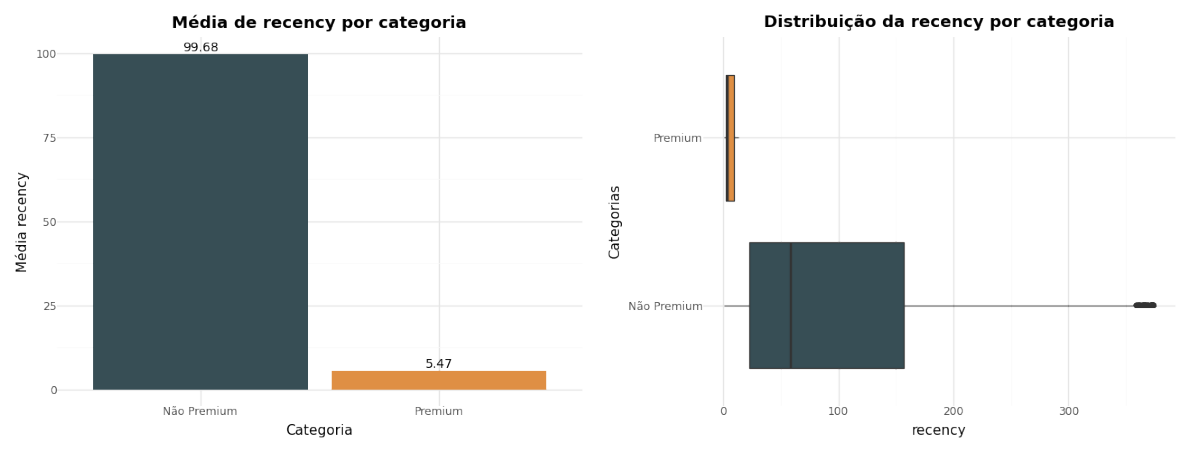

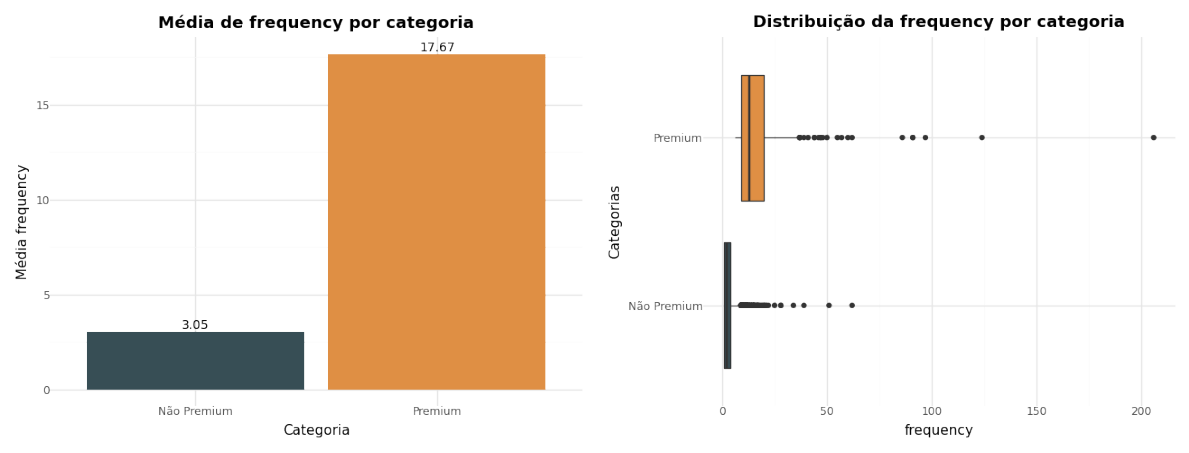

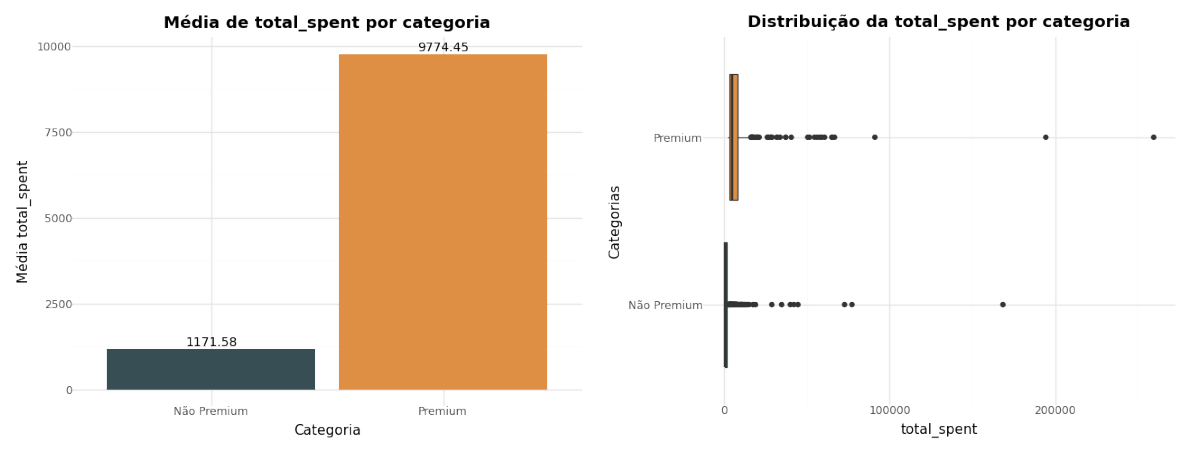

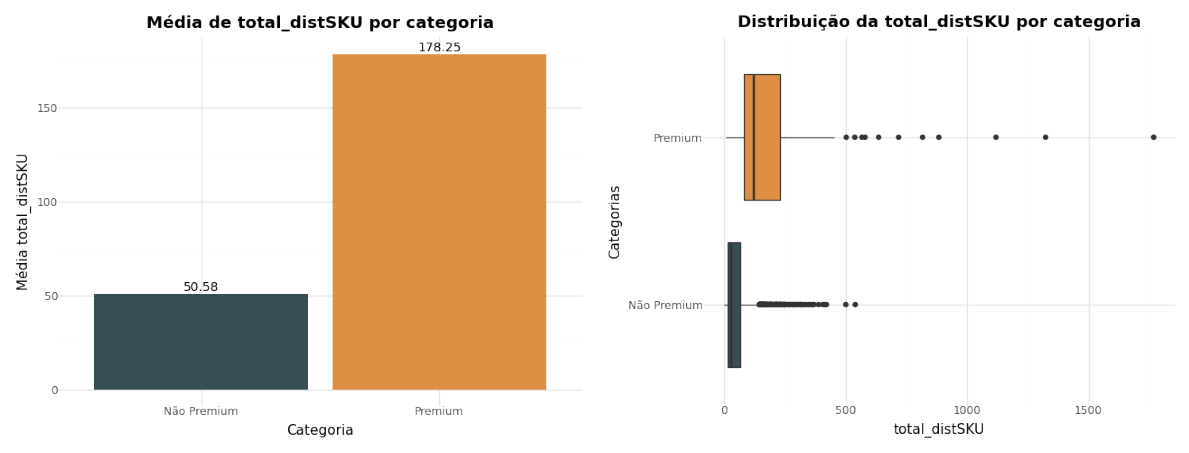

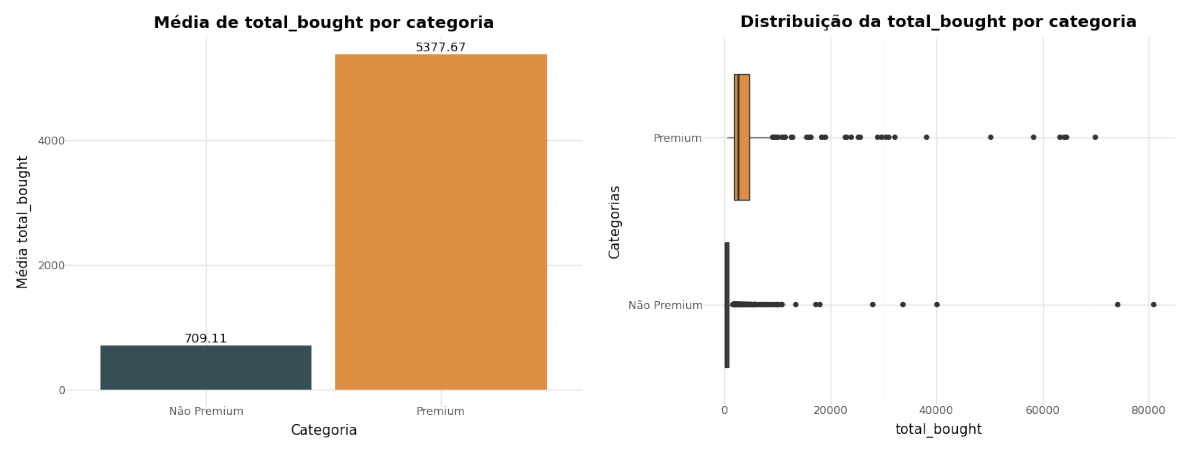

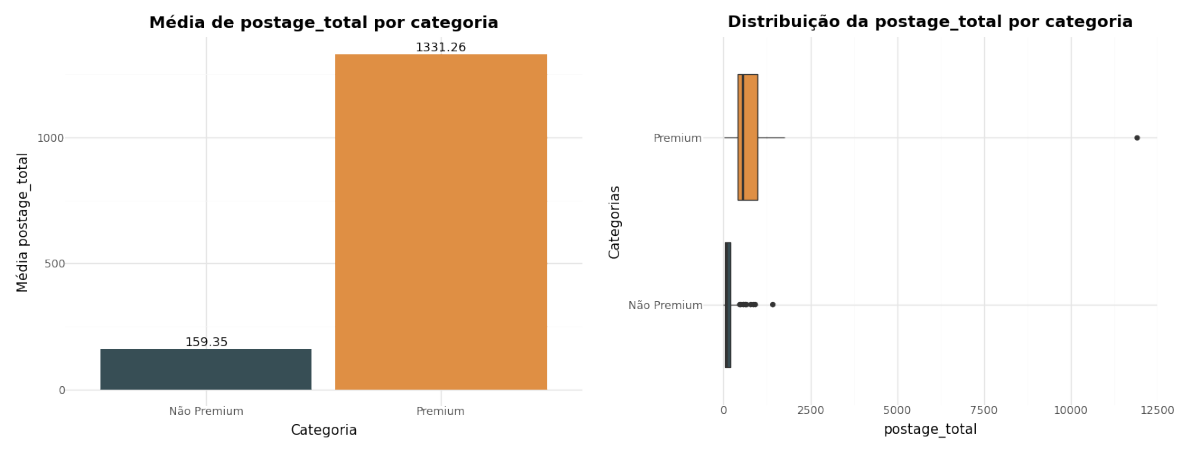

In [ ]:
for variavel in ['recency','frequency','total_spent','total_distSKU','total_bought','postage_total']:
  dt_plot = dt_customer[dt_customer[variavel] > 0].copy()

  plot1 = barplot_premiumcompare(dt_plot = dt_plot, yaxis = variavel, xlab = "Categoria", ylab = "Média " + variavel, title = f"Média de {variavel} por categoria")
  plot2 = boxplot_premiumcompare(dt_plot = dt_plot, xaxis = variavel, ylab = variavel, xlab = "Categorias", title = f"Distribuição da {variavel} por categoria")
  plot_side_by_side(plot1, plot2)

Optei por considerar somente os clientes do Reino Unido, Alemanha e França por serem os três países terem uma quantidade de clientes relevantes. Ações para aumentar o número de clientes em outros países podem ser interessantes.

Os clientes Premium, mesmo sendo cerca de 8% do universo de clientes, correspondem a 42,62% do faturamento da empresa. Esse dado por si só já demonstra a sua importância e justifica campanhas e condições específicas para esse grupo.

Escolhi os 6 indicadores abaixo para olharmos com mais profundidade:

**Recency:** a média de dias de recência é cerca de 100 vezes maior nos Não-Premium comparados os Premium. Além disso, a variabilidade é muito menor no Premium, o que indica alguma homogeneidade sobre esse quesito nos Premium.
- Dada a baixo recência, os clientes Premium são mais propensos a voltar para comprar no site. Então, direcionar anuncios de itens mais perecíveis para eles tem um bom potencial de aumentar o número de venda.
- Outro ponto, mas fora do tópico específico desse estudo é: como observar os clientes Não-Premium? Acredito que possa ser o tema de algum estudo futuro.

**Frequency:** a média da frequencia de transações para clientes Premium é 5 vezes maior. Além disso, no boxplot podemos observar que o P25 Premium é maior do que alguns outliers dos Não-Premium. Então, a frequência de comprar em Premium é definitivamente maior.
- Os clientes Premium compram com mais frequência, como esperado. Esse tipo de cliente pode estar mais sujeito a entrar em um programa de fidelidade. Uma análise mais aprofundada seria necessária desenhar um programa de fidelidade para os clientes Premium, mas acredito que seja um tipo de ação que ajuda a aumentar ainda mais a frequência de compras.


**TotalGastos:** a média do total gasto é cerca de 9 vezes maior nos clientes Premium. Em ambos os casos há muito outliers, mas a distribuição de concentra em valores maiores no Premium.
- O total gasto sozinho pode levar a intepretações erradas, sendo ideal ser analisado junto com a frequência. Um cliente recorrente é muito mais valioso ao longo prazo do que um cliente que faz uma compra grande. De todo modo, esse tipo de cliente também pode fazer bom proveito de um programa de fidelidade. Além disso, algum tipo de atendimento prioritario para quando ele tiver algum problema ou dúvida pode ajuda-lo a enxergar confiança na marca e continuar comprando.


**SKUsDistintos:** a média da quantidade de SKUs unicos é 3 vezes maior nos clientes Premium.
- Esse indicador ser alto aponta para um cliente "curioso", que pode estar mais sujeito a comprar produtos diferentes do que costuma comprar. Já esse indicador baixo aponta para um cliente com habitos mais "fixos", de modo que direcionar campanhas sobre produtos que já está acostumado a comprar, ou da mesma categoria, teriam mais efeito do que campanhas de produtos diferentes.


**TotalBought:** a média de quantidade de SKUs comprados é 7 vezes maior nos clientes Premium.
- A quantidade de itens comprados por um cliente pode ser usado para entender quando direcionar certas campanhas para esse tipo de cliente. Pode-se identificar a frequência com que ele compra grandes quantidade de um determinado produto para "avisa-lo" que já é hora de comprar novamente.


**TotalPostage:** Considerando somente os clientes que gastaram mais de zero libras com postagem, a média de gasto com postagem é 8 vezes maior nos clientes Premium.
- Um alto gasto com frete pode implicar o cliente comprar menos no site. Uma possibilidade é oferecer descontos ou frete grátis para esses clientes como forma de incentivá-los a realizar mais compras. Além disso, avaliar o trade-off em oferecer desconto no frete combinado com a inclusão de mais produtos no carrinho pode fazer com que o cliente economize na postagem e a empresa fature mais.






# Avançando nas análises - Recomendação de Produtos para clientes Premium

Abaixo vou implementar duas técnicas: Recomendação Simples e Cesta de Produtos.

# Recomendação Simples X Cesta de Produtos ***X Cesta de Produtos personalizada***

Recomendação Simples:
- Elencar os top 10 produtos mais comprados pelos clientes Premium e recomendá-los para quem ainda não os comprou.

Cesta de Produtos:
- Algoritmo analisa a propensão de um cliente comprar um produto B dado que comprou um produto A.

***Cesta de Produtos personalizada:***
- ***Criamos uma classificação dentro dos clientes Premium, algoritmo analisa a propensão de um cliente comprar um produto B dado que comprou um produto A dentro de cada grupo.*** **ideia abandonada com as análises a seguir **

### Proposta:

Vamos separar os clientes Premium em dois grupos aleatórios, aplicamos cada uma das técnicas acima para cada um dos grupos e ao final do período de testes comparamos os resultados de vendas através de um Teste A/B.

Veja que a Recomendação Simples é muito mais fácil de interpretar e implementar no sistema do que a Cesta de Produtos, então se ela se mostrar tão eficiente quanto podemos seguir com ela. Já caso a Cesta de Produtos se mostre mais eficiente, a implementamos.

Os dois casos podem ter suas listas de produtos atualizada a cada X tempo para uma maior eficiência do experimento.


In [ ]:
dt_treated['Flag_Premium'] = dt_treated["CustomerID"].isin(dt_premium["CustomerID"]).astype(int)
dt_customer_premium = dt_treated[dt_treated["Flag_Premium"] == 1].merge(dt_rfm[['CustomerID', 'recency',	'frequency', 'total_spent']])

## Recomendação simples

In [ ]:
top_products = (
    dt_customer_premium
    .groupby("Description")
    .agg(
        total_bought = ("Quantity", "sum")
    )
    .sort_values(by = "total_bought", ascending=False)
    .head(10)
)

print(top_products)

                                    total_bought
Description                                     
WORLD WAR 2 GLIDERS ASSTD DESIGNS          25463
JUMBO BAG RED RETROSPOT                    22931
POPCORN HOLDER                             17927
WHITE HANGING HEART T-LIGHT HOLDER         16331
PACK OF 12 LONDON TISSUES                  14888
VICTORIAN GLASS HANGING T-LIGHT            12661
ASSORTED COLOUR BIRD ORNAMENT              11761
RED  HARMONICA IN BOX                      11019
JUMBO BAG PINK POLKADOT                    10969
PACK OF 60 PINK PAISLEY CAKE CASES          9686


## Cesta de Produtos

In [ ]:

basket = dt_customer_premium.pivot_table(
    index="InvoiceNo",
    columns="Description",
    values="Quantity",
    fill_value=0
)

basket = basket > 0

freq_items = apriori(basket, min_support=0.01, use_colnames=True)

In [ ]:
rules = association_rules(freq_items, metric="lift", min_threshold=9)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(60 TEATIME FAIRY CAKE CASES),(72 SWEETHEART FAIRY CAKE CASES),0.031757,0.026182,0.010304,0.324468,12.392588,1.0,0.009473,1.441557,0.949458,0.216312,0.306305,0.359008
1,(72 SWEETHEART FAIRY CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.026182,0.031757,0.010304,0.393548,12.392588,1.0,0.009473,1.596571,0.944023,0.216312,0.373658,0.359008
2,(PACK OF 60 DINOSAUR CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.029054,0.031757,0.010980,0.377907,11.900049,1.0,0.010057,1.556428,0.943376,0.220339,0.357503,0.361826
3,(60 TEATIME FAIRY CAKE CASES),(PACK OF 60 DINOSAUR CAKE CASES),0.031757,0.029054,0.010980,0.345745,11.900049,1.0,0.010057,1.484047,0.946009,0.220339,0.326167,0.361826
4,(PACK OF 60 PINK PAISLEY CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.034797,0.031757,0.015372,0.441748,13.910349,1.0,0.014267,1.734418,0.961571,0.300330,0.423438,0.462895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,"(LUNCH BAG SPACEBOY DESIGN, LUNCH BAG SUKI DES...","(LUNCH BAG RED RETROSPOT, LUNCH BAG WOODLAND)",0.022635,0.030068,0.010304,0.455224,15.140030,1.0,0.009623,1.780424,0.955580,0.243028,0.438336,0.398960
916,(LUNCH BAG RED RETROSPOT),"(LUNCH BAG WOODLAND, LUNCH BAG SPACEBOY DESIGN...",0.087669,0.012669,0.010304,0.117534,9.277328,1.0,0.009193,1.118832,0.977946,0.114447,0.106210,0.465434
917,(LUNCH BAG WOODLAND),"(LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY D...",0.051182,0.015372,0.010304,0.201320,13.096870,1.0,0.009517,1.232820,0.973470,0.183183,0.188851,0.435825
918,(LUNCH BAG SPACEBOY DESIGN),"(LUNCH BAG RED RETROSPOT, LUNCH BAG WOODLAND, ...",0.056419,0.015709,0.010304,0.182635,11.625781,1.0,0.009418,1.204224,0.968634,0.166667,0.169589,0.419274


In [ ]:
dt_customer_premium[['recency',	'frequency',	'total_spent']].drop_duplicates().copy()

,recency,frequency,total_spent
0,3,15.0,7281.38
20,8,21.0,5579.10
39,1,30.0,60632.75
74,3,30.0,91062.38
98,2,30.0,28117.04
...,...,...,...
85797,7,6.0,2050.08
86032,4,9.0,2108.06
86522,3,7.0,3119.44
88707,4,8.0,3974.75


In [ ]:
# Cesta de Produtos personalizada

# 1) clusterização
clustering_data = dt_customer_premium[['recency',	'frequency',	'total_spent']].drop_duplicates().copy()

scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

clust = list(range(2, 10))
s_scores = []

for c in clust:
    kmeans = KMeans(n_clusters = c, random_state = 5042026)
    kmeans_model = kmeans.fit(clustering_data_scaled)
    kmeans_preds = kmeans.predict(clustering_data_scaled)
    s_scores.append(silhouette_score(clustering_data, kmeans_preds))

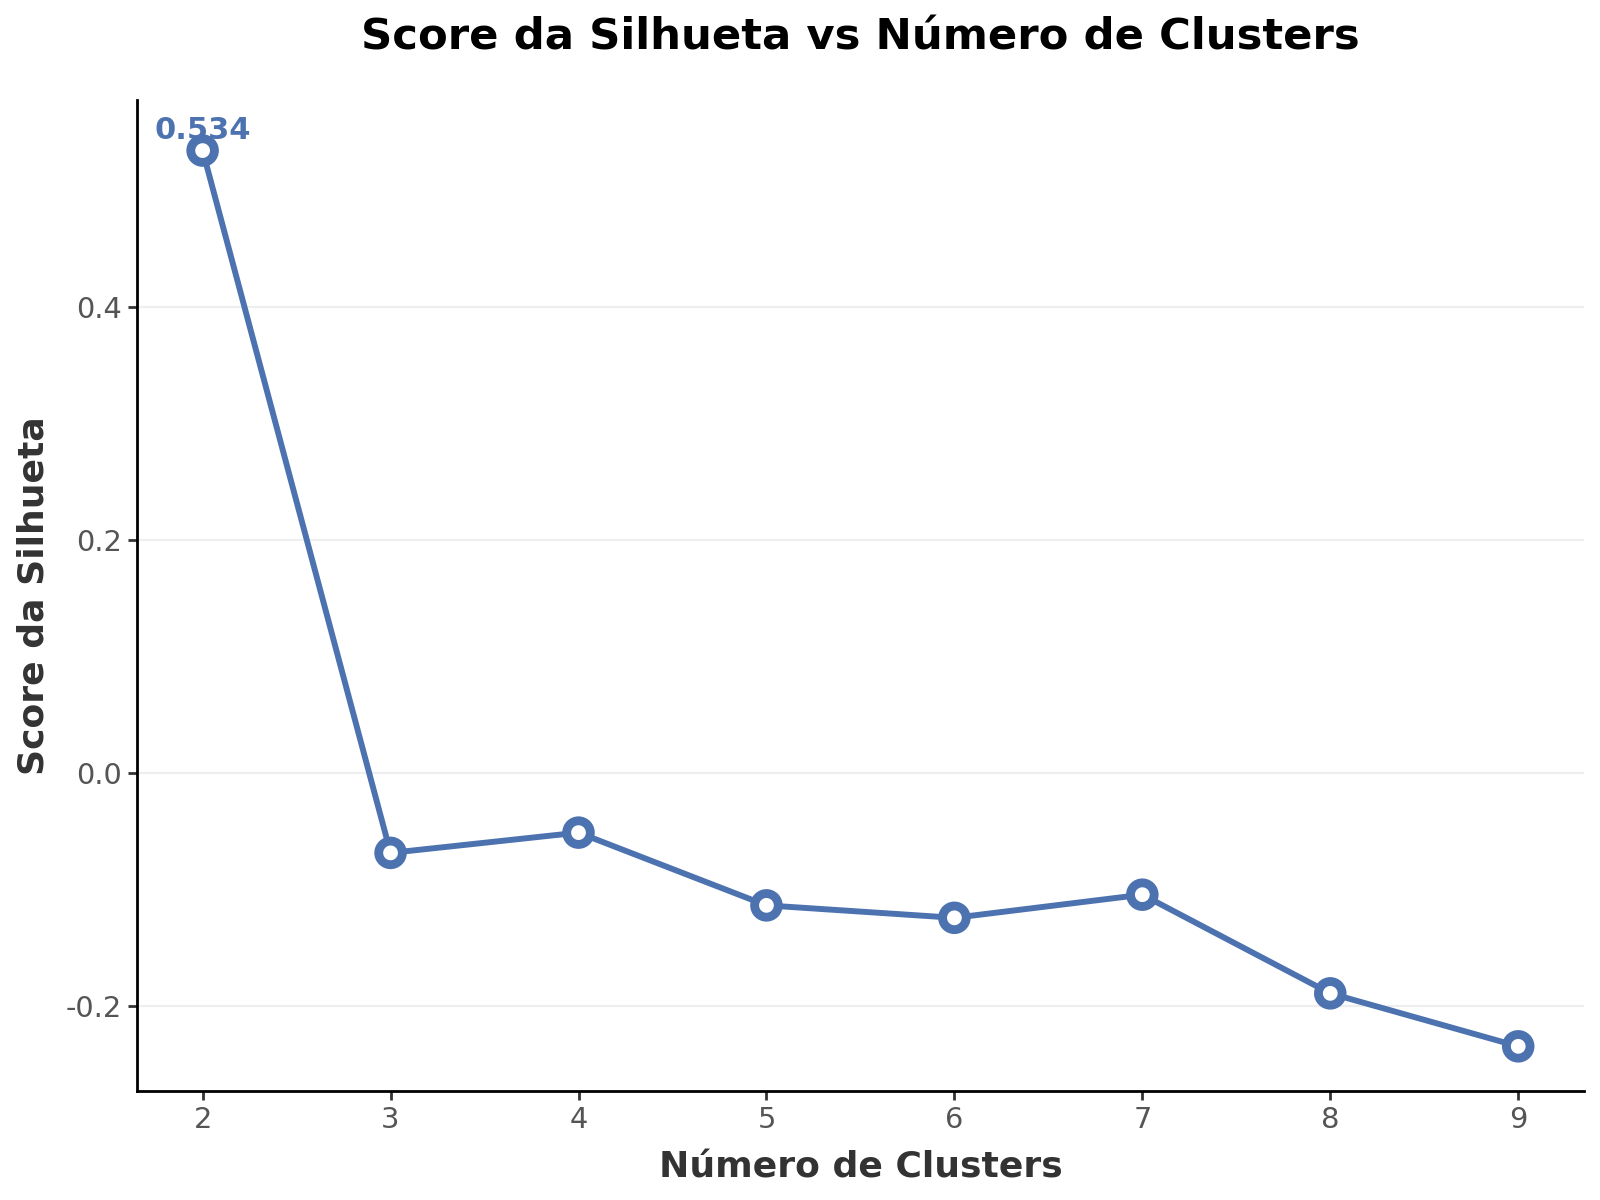

In [ ]:
df = pd.DataFrame({"clust": clust, "s_scores": s_scores})

df["label"] = df["s_scores"].apply(lambda x: f"{x:.3f}" if x == df["s_scores"].max() else "")

(
    ggplot(df, aes(x="clust", y="s_scores"))
    + geom_line(color="#4C72B0", size=1.2)
    + geom_point(color="#4C72B0", fill="white", size=3, stroke=1.8, shape="o")
    + geom_text(aes(label="label"), va="bottom", nudge_y=0.005, size=11, fontweight="bold", color="#4C72B0")
    + scale_x_continuous(breaks=clust)
    + labs(
        x="Número de Clusters",
        y="Score da Silhueta",
        title="Score da Silhueta vs Número de Clusters",
    )
    + theme_classic(base_size=13)
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(face="bold", hjust=0.5, margin={"b": 15}),
        axis_title=element_text(face="bold", color="#333333"),
        axis_text=element_text(color="#555555"),
        panel_grid_major_y=element_line(color="#eeeeee", size=0.8),
        plot_background=element_rect(fill="white"),
    )
)

O silhouette score é um indicador entre 1 e -1, onde quanto mais próximo de 1 mais bem definidos são os clusters. Ou seja, melhor os clusters separam os clientes.

In [ ]:
def boxplot_clustercompare(dt_plot, xaxis, xlab = "", ylab = "Categoria", title = ""):
    boxplot_chart = (
                      ggplot(dt_plot, aes(x="factor(Cluster_classif)", y=xaxis, fill="factor(Cluster_classif)"))
                      + geom_boxplot(alpha=0.7)
                      + scale_fill_manual(values=["#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF"], guide=None)
                      + labs(
                          title=title,
                          x=xlab,
                          y=ylab
                      )
                      + theme_minimal()
                      + theme(plot_title=element_text(weight="bold"))
                    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    boxplot_chart.draw()._repr_html_()

    # Extract figures and combine
    fig1 = boxplot_chart.draw()

    # Copy axes from each plotnine figure into subplots
    fig1.axes[0].get_figure().canvas.draw()

    axes[0].imshow(fig1.canvas.buffer_rgba())

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

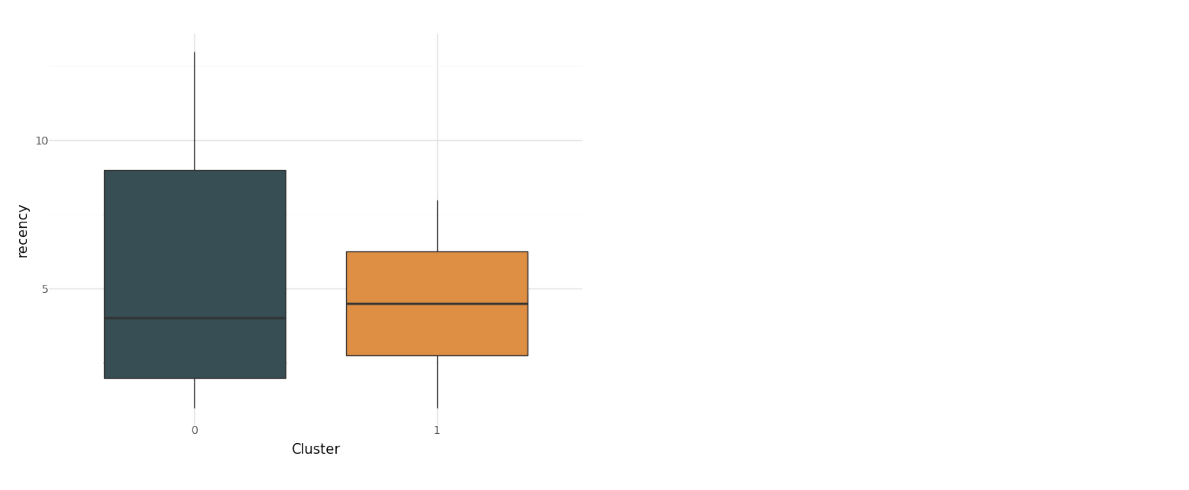

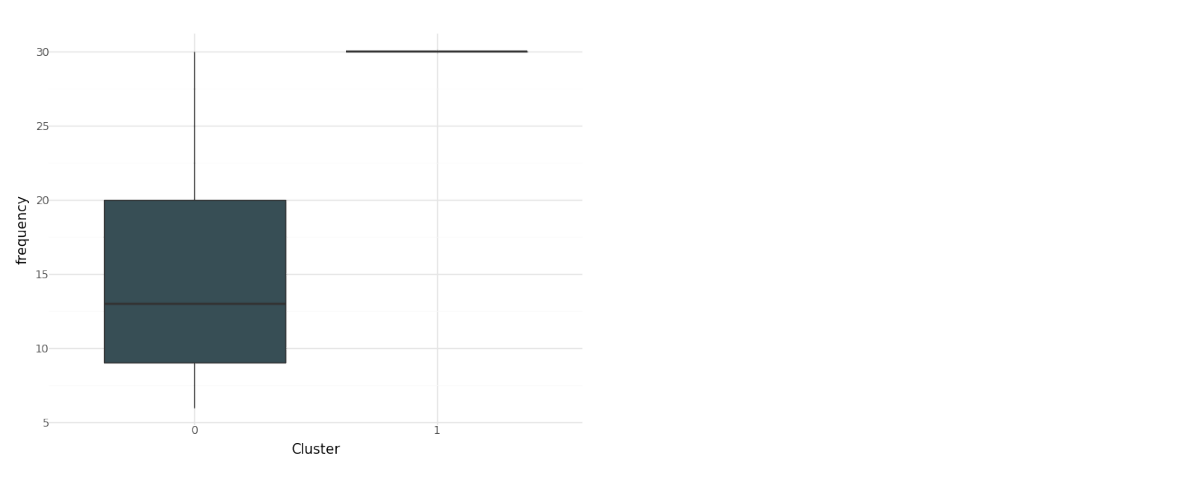

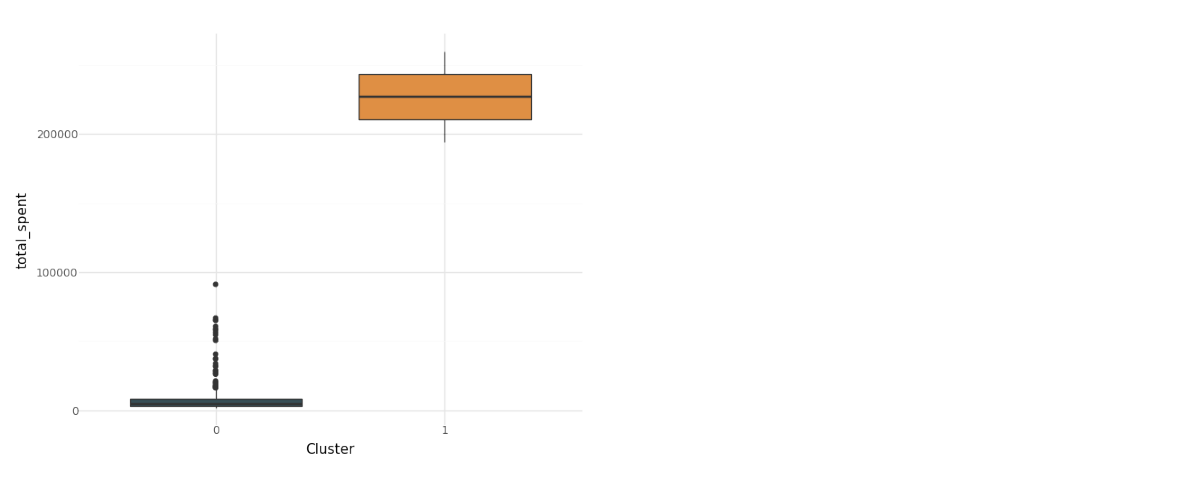

Cluster_classif
0    333
1      2
Name: count, dtype: int64


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=5042026)
kmeans.fit(clustering_data)
kmeans_preds = kmeans.predict(clustering_data)
clustering_data = clustering_data.assign(Cluster_classif = kmeans_preds)

xaxis = ['recency',	'frequency',	'total_spent']

for x in xaxis:
  boxplot_clustercompare(clustering_data, xaxis = x, xlab = "Cluster", ylab = x, title = "")

print(clustering_data['Cluster_classif'].value_counts())

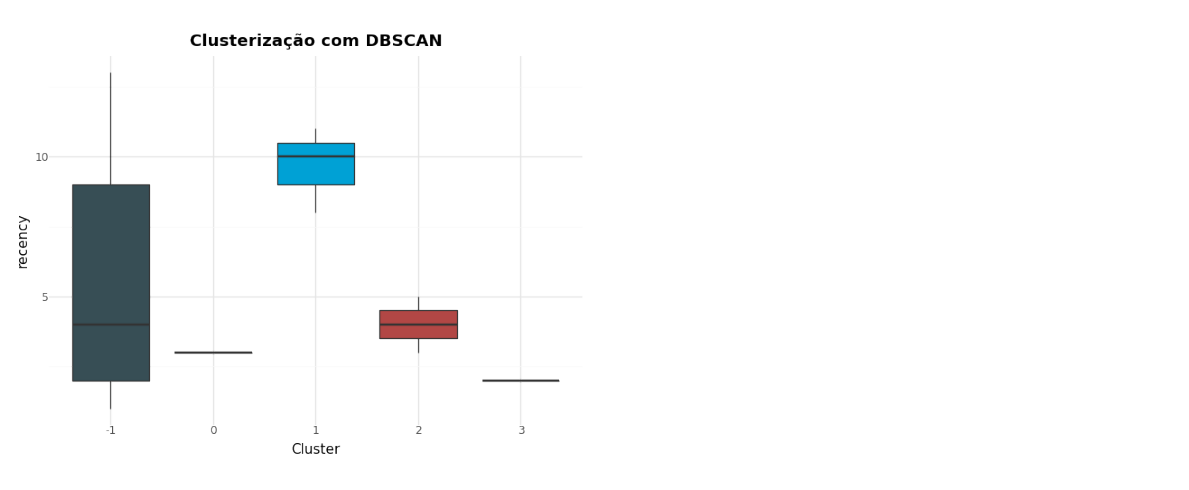

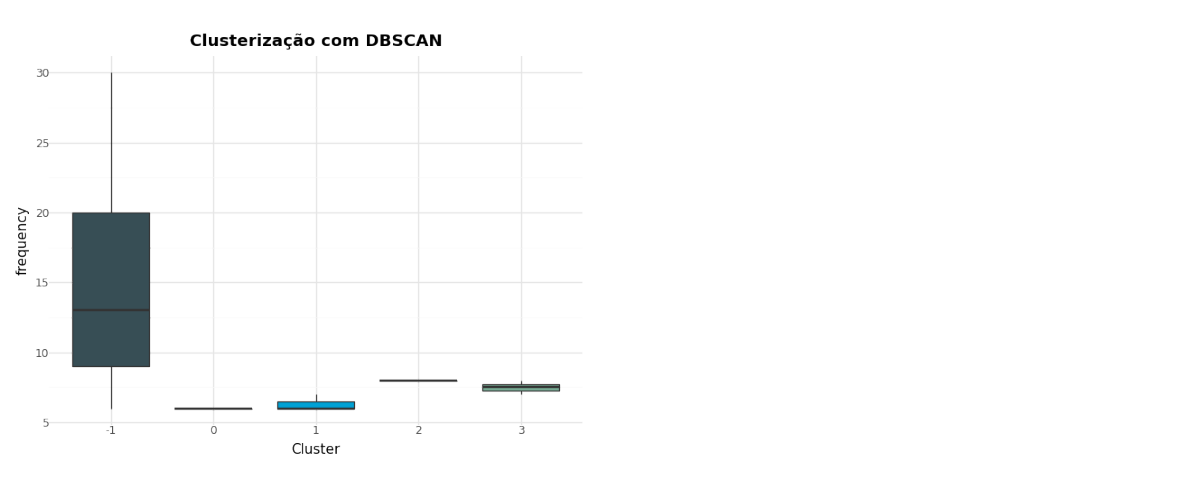

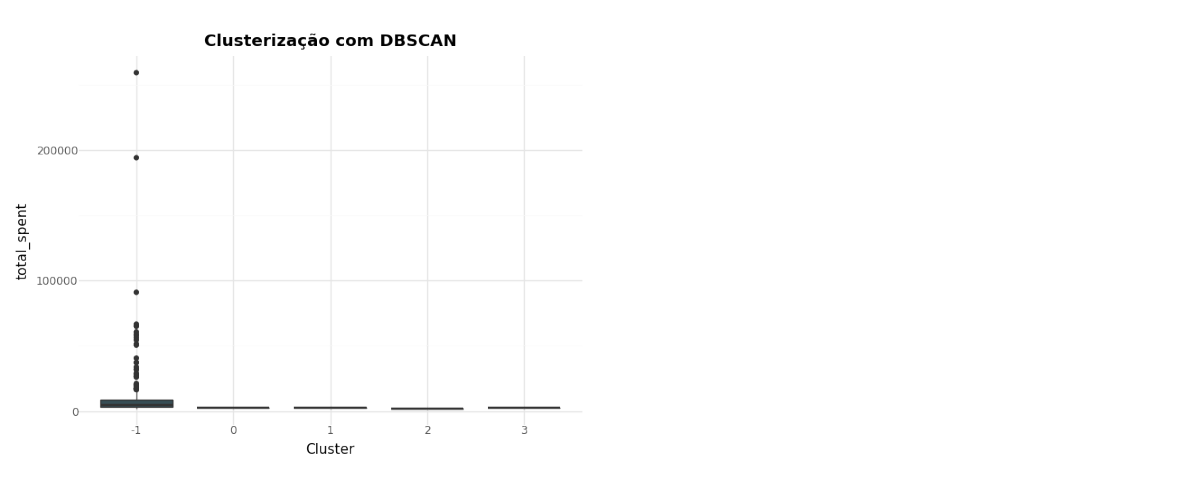

Cluster_classif
-1    326
 1      3
 0      2
 2      2
 3      2
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import DBSCAN

dbscan_c = DBSCAN(eps=3, min_samples=2)
dbscan_c.fit(clustering_data)
dbscan_c_preds = dbscan_c.fit_predict(clustering_data)
clustering_data = clustering_data.assign(Cluster_classif = dbscan_c_preds)

xaxis = ['recency',	'frequency',	'total_spent']

for x in xaxis:
  boxplot_clustercompare(clustering_data, xaxis = x, xlab = "Cluster", ylab = x, title = "Clusterização com DBSCAN")

print(clustering_data['Cluster_classif'].value_counts())

A clusterização não retornou bons resultados, tanto com KMeans quanto com DBSCAN. Isso indica já uma boa homogeneidade na classificação de clientes Premium. De todo modo, vou seguir com a proposta da Recomendação Simples e com a Cesta de Produtos somente.